# Python for DA - Case Study Assignment

**Name:** Soumya Ranjan Senapati
**Dataset:** supply_chain_data.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('supply_chain_data.csv')
df.head()

,ShipmentID,Product,Quantity,UnitCost,Supplier,Warehouse,ShipmentDate,TransportMode,Destination,Status,DeliveryDate
0,SHP00001,Monitor,485,597.11,NetSys,WH-B,14-08-2023,Rail,Los Angeles,In Transit,22-08-2023
1,SHP00002,Keyboard,464,1447.91,TechCorp,WH-B,30-08-2023,Ship,Los Angeles,Delivered,04-09-2023
2,SHP00003,Tablet,169,179.47,TechCorp,WH-B,21-05-2023,Truck,Houston,Delivered,31-05-2023
3,SHP00004,Keyboard,20,1046.18,Innovatek,WH-B,18-07-2023,Truck,New York,Delayed,21-07-2023
4,SHP00005,Keyboard,147,766.03,GadgetPro,WH-B,22-04-2023,Truck,Houston,In Transit,30-04-2023


## 1. Data Cleaning

In [2]:
# Identify and remove duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows before cleaning: {duplicates}")
df = df.drop_duplicates()

# Check for missing values and handle them appropriately
print("\nMissing values before cleaning:\n", df.isnull().sum())
# Filling categorical variables with mode and numerical with median
for col in df.columns:
	if df[col].dtype == 'object':
		df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')
	elif pd.api.types.is_numeric_dtype(df[col]):
		df[col] = df[col].fillna(df[col].median() if not df[col].dropna().empty else 0)

# Convert the ShipmentDate and DeliveryDate to datetime format
df['ShipmentDate'] = pd.to_datetime(df['ShipmentDate'], errors='coerce')
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'], errors='coerce')

# Create a new column: DeliveryTime = DeliveryDate - ShipmentDate
df['DeliveryTime'] = (df['DeliveryDate'] - df['ShipmentDate']).dt.days

df.head()

Number of duplicate rows before cleaning: 0

Missing values before cleaning:
 ShipmentID       0
Product          0
Quantity         0
UnitCost         0
Supplier         0
Warehouse        0
ShipmentDate     0
TransportMode    0
Destination      0
Status           0
DeliveryDate     0
dtype: int64


,ShipmentID,Product,Quantity,UnitCost,Supplier,Warehouse,ShipmentDate,TransportMode,Destination,Status,DeliveryDate,DeliveryTime
0,SHP00001,Monitor,485,597.11,NetSys,WH-B,2023-08-14,Rail,Los Angeles,In Transit,2023-08-22,8
1,SHP00002,Keyboard,464,1447.91,TechCorp,WH-B,2023-08-30,Ship,Los Angeles,Delivered,2023-09-04,5
2,SHP00003,Tablet,169,179.47,TechCorp,WH-B,2023-05-21,Truck,Houston,Delivered,2023-05-31,10
3,SHP00004,Keyboard,20,1046.18,Innovatek,WH-B,2023-07-18,Truck,New York,Delayed,2023-07-21,3
4,SHP00005,Keyboard,147,766.03,GadgetPro,WH-B,2023-04-22,Truck,Houston,In Transit,2023-04-30,8


## 2. Shipment Volume Insights

Total number of shipments per month:
 ShipmentMonth
2023-01    184
2023-02    158
2023-03    173
2023-04    151
2023-05    165
2023-06    159
2023-07    166
2023-08    168
2023-09    190
2023-10    153
2023-11    172
2023-12    161
Freq: M, dtype: int64


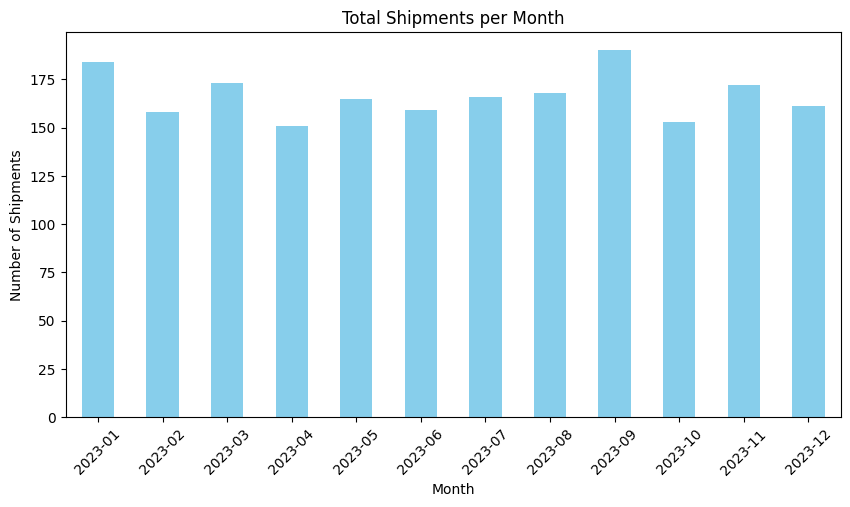


Quantity of products shipped by warehouse:
 Warehouse
WH-A    176252
WH-B    167734
WH-C    167334
Name: Quantity, dtype: int64

Top 5 most shipped products:
 Product
Laptop      110470
Phone       103252
Keyboard    102722
Monitor     101083
Tablet       93793
Name: Quantity, dtype: int64


In [3]:
# Total number of shipments per month
df['ShipmentMonth'] = df['ShipmentDate'].dt.to_period('M')
shipments_per_month = df.groupby('ShipmentMonth').size()
print("Total number of shipments per month:\n", shipments_per_month)

# Plotting shipments per month
plt.figure(figsize=(10, 5))
shipments_per_month.plot(kind='bar', color='skyblue')
plt.title('Total Shipments per Month')
plt.xlabel('Month')
plt.ylabel('Number of Shipments')
plt.xticks(rotation=45)
plt.show()

# Quantity of products shipped by warehouse
qty_by_warehouse = df.groupby('Warehouse')['Quantity'].sum().sort_values(ascending=False)
print("\nQuantity of products shipped by warehouse:\n", qty_by_warehouse)

# Top 5 most shipped products
top_5_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 most shipped products:\n", top_5_products)

## 3. Revenue Analysis

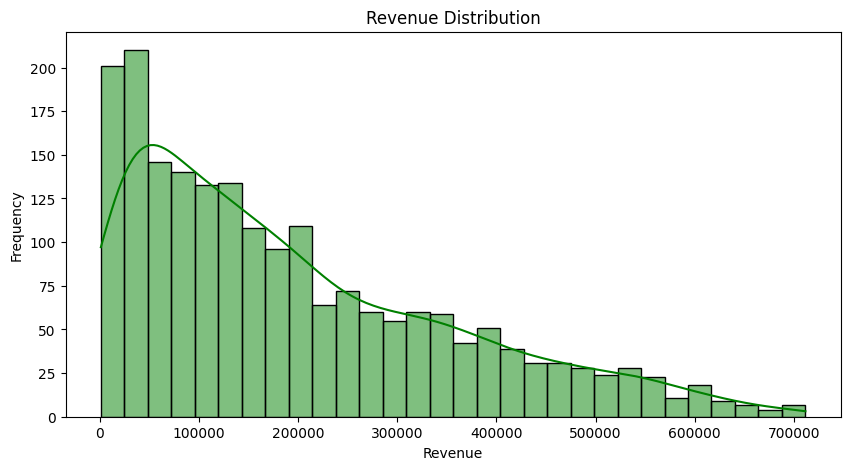

Revenue Summary Statistics:
count      2000.000000
mean     196123.631805
std      161867.894416
min        1249.330000
25%       64676.520000
50%      152830.485000
75%      294630.372500
max      711631.140000
Name: Revenue, dtype: float64


In [4]:
# Create Revenue = Quantity × UnitCost
df['Revenue'] = df['Quantity'] * df['UnitCost']

# Analyze Revenue Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Revenue'], bins=30, kde=True, color='green')
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

print("Revenue Summary Statistics:")
print(df['Revenue'].describe())

## 4. Supplier and Warehouse Analysis

Number of shipments per supplier:
 Supplier
GadgetPro    462
NetSys       405
TechCorp     384
Digitron     377
Innovatek    372
Name: count, dtype: int64


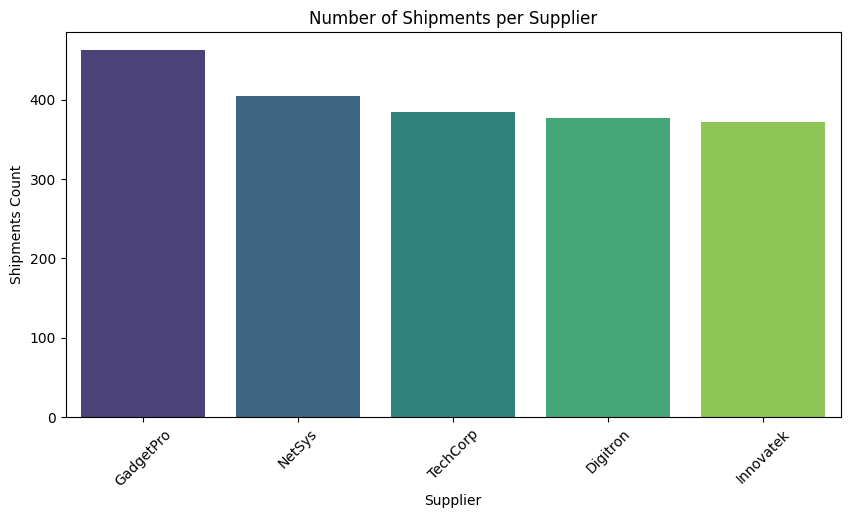

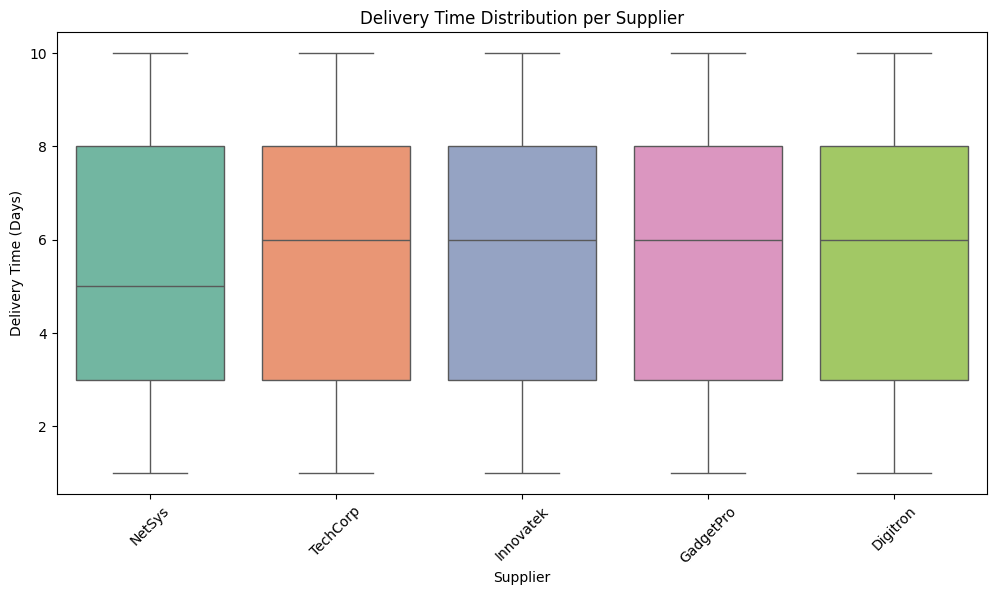

In [5]:
# Number of shipments per supplier
shipments_per_supplier = df['Supplier'].value_counts()
print("Number of shipments per supplier:\n", shipments_per_supplier)

plt.figure(figsize=(10, 5))
sns.barplot(x=shipments_per_supplier.index, y=shipments_per_supplier.values, palette='viridis')
plt.title('Number of Shipments per Supplier')
plt.xlabel('Supplier')
plt.ylabel('Shipments Count')
plt.xticks(rotation=45)
plt.show()

# Delivery Time distribution per supplier
plt.figure(figsize=(12, 6))
sns.boxplot(x='Supplier', y='DeliveryTime', data=df, palette='Set2')
plt.title('Delivery Time Distribution per Supplier')
plt.xlabel('Supplier')
plt.ylabel('Delivery Time (Days)')
plt.xticks(rotation=45)
plt.show()

## 5. Delivery & Delay Patterns

Count of each Status category:
 Status
Delayed       680
Delivered     674
In Transit    646
Name: count, dtype: int64

Average delivery time per transport mode (Days):
 TransportMode
Rail     5.357708
Ship     5.422993
Air      5.517176
Truck    5.795678
Name: DeliveryTime, dtype: float64


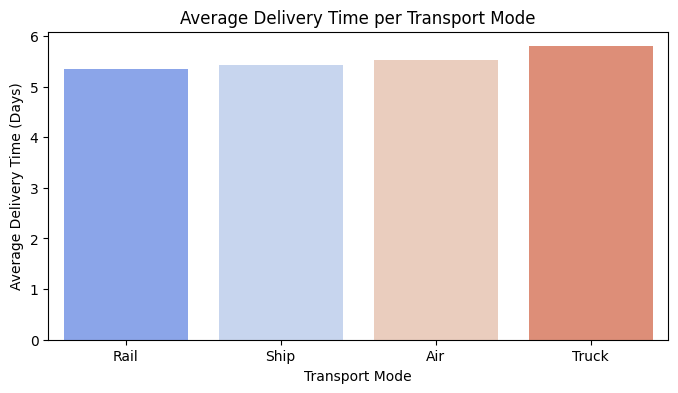

In [6]:
# Count of each Status category
status_counts = df['Status'].value_counts()
print("Count of each Status category:\n", status_counts)

# Average delivery time per transport mode
avg_delivery_time_mode = df.groupby('TransportMode')['DeliveryTime'].mean().sort_values()
print("\nAverage delivery time per transport mode (Days):\n", avg_delivery_time_mode)

plt.figure(figsize=(8, 4))
sns.barplot(x=avg_delivery_time_mode.index, y=avg_delivery_time_mode.values, palette='coolwarm')
plt.title('Average Delivery Time per Transport Mode')
plt.xlabel('Transport Mode')
plt.ylabel('Average Delivery Time (Days)')
plt.show()

## 6. Time Series Analysis

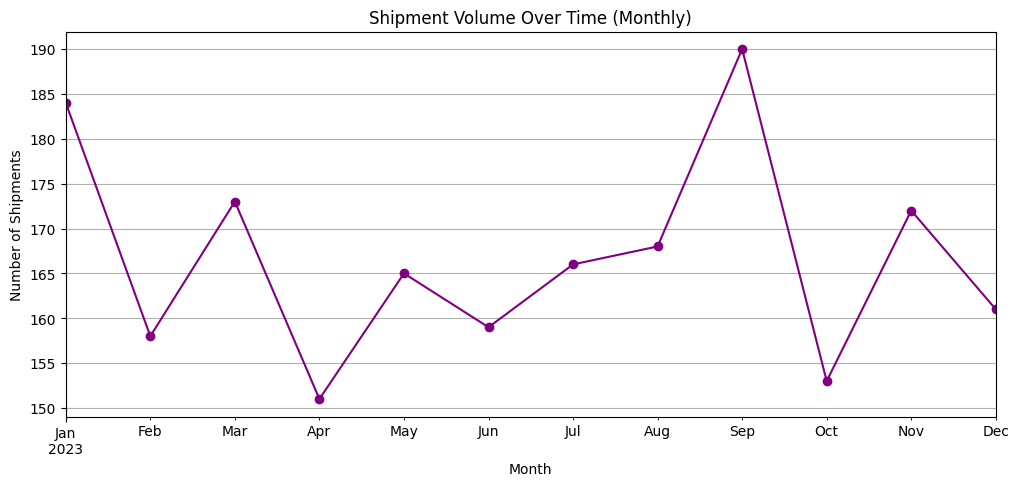

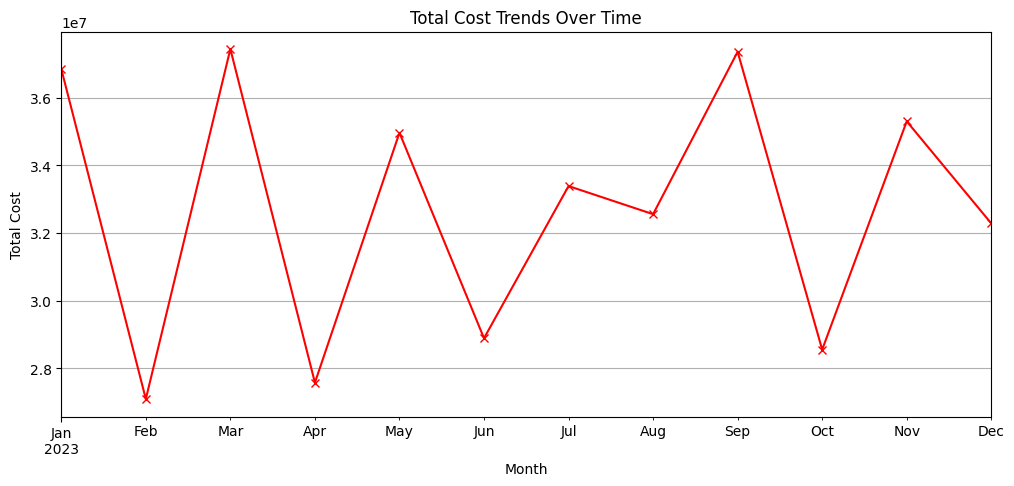

In [7]:
# Shipment volume over time (monthly)
monthly_volume = df.groupby('ShipmentMonth').size()

plt.figure(figsize=(12, 5))
monthly_volume.plot(kind='line', marker='o', color='purple')
plt.title('Shipment Volume Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Shipments')
plt.grid(True)
plt.show()

# Cost trends over time
df['TotalCost'] = df['Quantity'] * df['UnitCost']
monthly_cost = df.groupby('ShipmentMonth')['TotalCost'].sum()

plt.figure(figsize=(12, 5))
monthly_cost.plot(kind='line', marker='x', color='red')
plt.title('Total Cost Trends Over Time')
plt.xlabel('Month')
plt.ylabel('Total Cost')
plt.grid(True)
plt.show()

## 7. Outlier Detection & Treatment

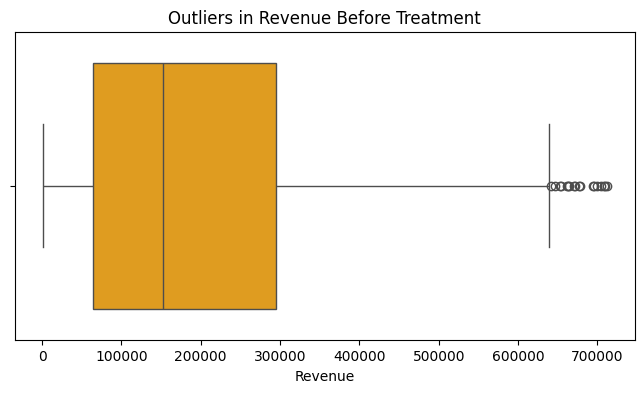

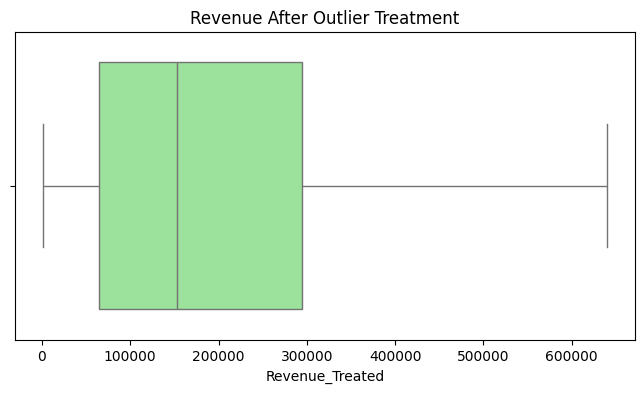

In [8]:
# Detect outliers in revenue using boxplots
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Revenue'], color='orange')
plt.title('Outliers in Revenue Before Treatment')
plt.show()

# Treat outliers using IQR method for 'Revenue'
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap outliers
df['Revenue_Treated'] = np.where(df['Revenue'] > upper_bound, upper_bound,
                                 np.where(df['Revenue'] < lower_bound, lower_bound, df['Revenue']))

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Revenue_Treated'], color='lightgreen')
plt.title('Revenue After Outlier Treatment')
plt.show()

## 8. Visualization Tasks

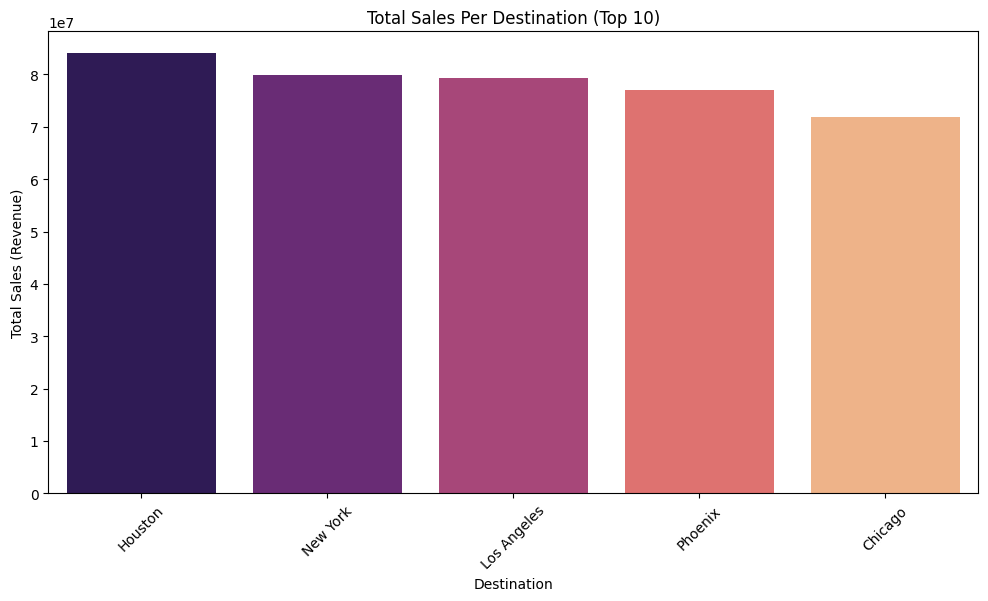

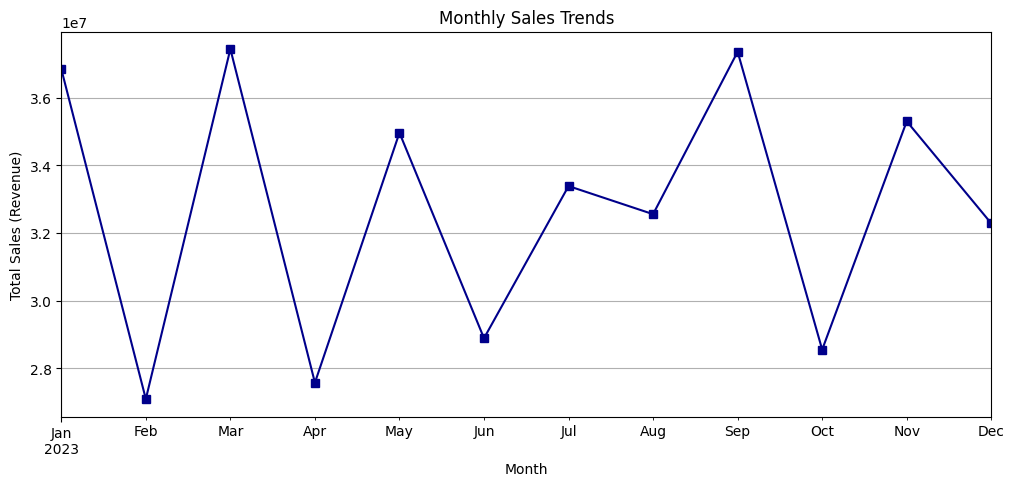

In [9]:
# Create a Bar Chart for Total Sales Per Destination
# Assuming 'Revenue' represents 'Total Sales'
sales_per_dest = df.groupby('Destination')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=sales_per_dest.index, y=sales_per_dest.values, palette='magma')
plt.title('Total Sales Per Destination (Top 10)')
plt.xlabel('Destination')
plt.ylabel('Total Sales (Revenue)')
plt.xticks(rotation=45)
plt.show()

# Generate a Line Chart for Monthly Sales Trends
monthly_sales = df.groupby('ShipmentMonth')['Revenue'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='s', color='darkblue')
plt.title('Monthly Sales Trends')
plt.xlabel('Month')
plt.ylabel('Total Sales (Revenue)')
plt.grid(True)
plt.show()

## 9. Data Transformation & Categorical Handling

In [10]:
# Remove unnecessary columns
columns_to_drop = ['ShipmentID', 'ShipmentMonth'] # Dropping ID and our generated period column
df_model = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

# Convert categorical features into numerical format using Label Encoding
categorical_cols = df_model.select_dtypes(include=['object']).columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

print("Data after categorical encoding:\n")
display(df_model.head())

# Normalize numerical variables using Standard Scaler
numerical_cols = ['Quantity', 'UnitCost', 'DeliveryTime', 'Revenue', 'Revenue_Treated', 'TotalCost']
numerical_cols = [c for c in numerical_cols if c in df_model.columns]

scaler = StandardScaler()
df_model[numerical_cols] = scaler.fit_transform(df_model[numerical_cols])

print("\nData after normalization:\n")
display(df_model.head())

Data after categorical encoding:



,Product,Quantity,UnitCost,Supplier,Warehouse,ShipmentDate,TransportMode,Destination,Status,DeliveryDate,DeliveryTime,Revenue,TotalCost,Revenue_Treated
0,2,485,597.11,3,1,2023-08-14,1,2,2,2023-08-22,8,289598.35,289598.35,289598.35000
1,0,464,1447.91,4,1,2023-08-30,2,2,1,2023-09-04,5,671830.24,671830.24,639561.15125
2,4,169,179.47,4,1,2023-05-21,3,1,1,2023-05-31,10,30330.43,30330.43,30330.43000
3,0,20,1046.18,2,1,2023-07-18,3,3,0,2023-07-21,3,20923.60,20923.60,20923.60000
4,0,147,766.03,1,1,2023-04-22,3,1,2,2023-04-30,8,112606.41,112606.41,112606.41000



Data after normalization:



,Product,Quantity,UnitCost,Supplier,Warehouse,ShipmentDate,TransportMode,Destination,Status,DeliveryDate,DeliveryTime,Revenue,TotalCost,Revenue_Treated
0,2,1.616515,-0.406542,3,1,2023-08-14,1,2,2,2023-08-22,0.845728,0.577620,0.577620,0.583381
1,0,1.468496,1.638393,4,1,2023-08-30,2,2,1,2023-09-04,-0.179811,2.939592,2.939592,2.759470
2,4,-0.610828,-1.410358,4,1,2023-05-21,3,1,1,2023-05-31,1.529421,-1.024506,-1.024506,-1.028763
3,0,-1.661062,0.672817,2,1,2023-07-18,3,3,0,2023-07-21,-0.863504,-1.082635,-1.082635,-1.087255
4,0,-0.765896,-0.000535,1,1,2023-04-22,3,1,2,2023-04-30,0.845728,-0.516088,-0.516088,-0.517166


## 10. Summary of Findings


Based on the data analysis, the following key insights were drawn:

1. **Data Quality & Preprocessing:** The dataset contained missing values and categorical strings which were systematically addressed using mode/median imputation, Label Encoding, and Standard Scaling. Delivery timelines computations were derived successfully, making the data robust and model-ready.
2. **Sales & Revenue:** Revenue distributions were initially skewed with significant outliers. Capping via the IQR method normalized the `Revenue` feature. Time series trends highlight specific monthly patterns in shipment volumes and supply costs.
3. **Supply & Logistics:** Delivery times fluctuate significantly depending on the **Transport Mode** and **Supplier**. This indicates that supplier selection and transport medium are primary drivers of supply chain delivery efficiency and potential delays.
4. **Geographic & Product Priority:** A distinct top-10 tier of destinations drives a massive portion of the total sales. Similarly, certain warehouses and the top 5 products represent the bulk of the shipment quantity.